Processing Training: 100%|█████████████████████████████████████████████████████████████| 13/13 [00:06<00:00,  2.03it/s]


Training Set: Preprocessed Successfully!


Processing Testing: 100%|██████████████████████████████████████████████████████████████| 13/13 [00:01<00:00,  8.43it/s]


Testing Set: Preprocessed Successfully!
 All preprocessing done. Saved as 'processed_data.npz'
Training Set: (4172, 64, 64, 1), Classes: 13


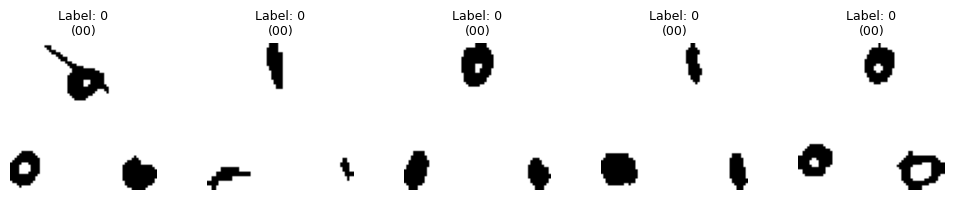

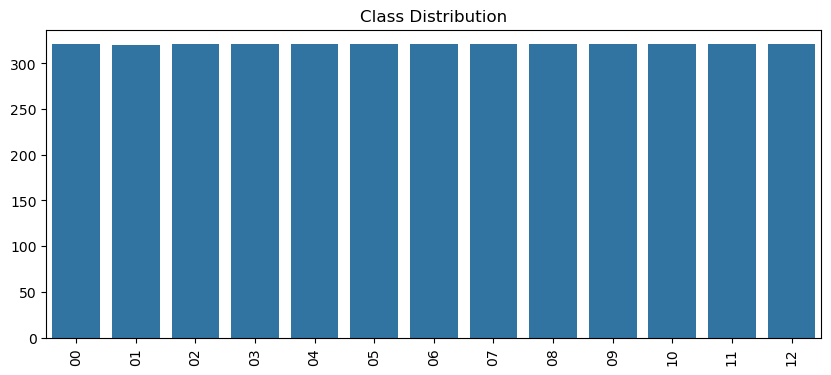

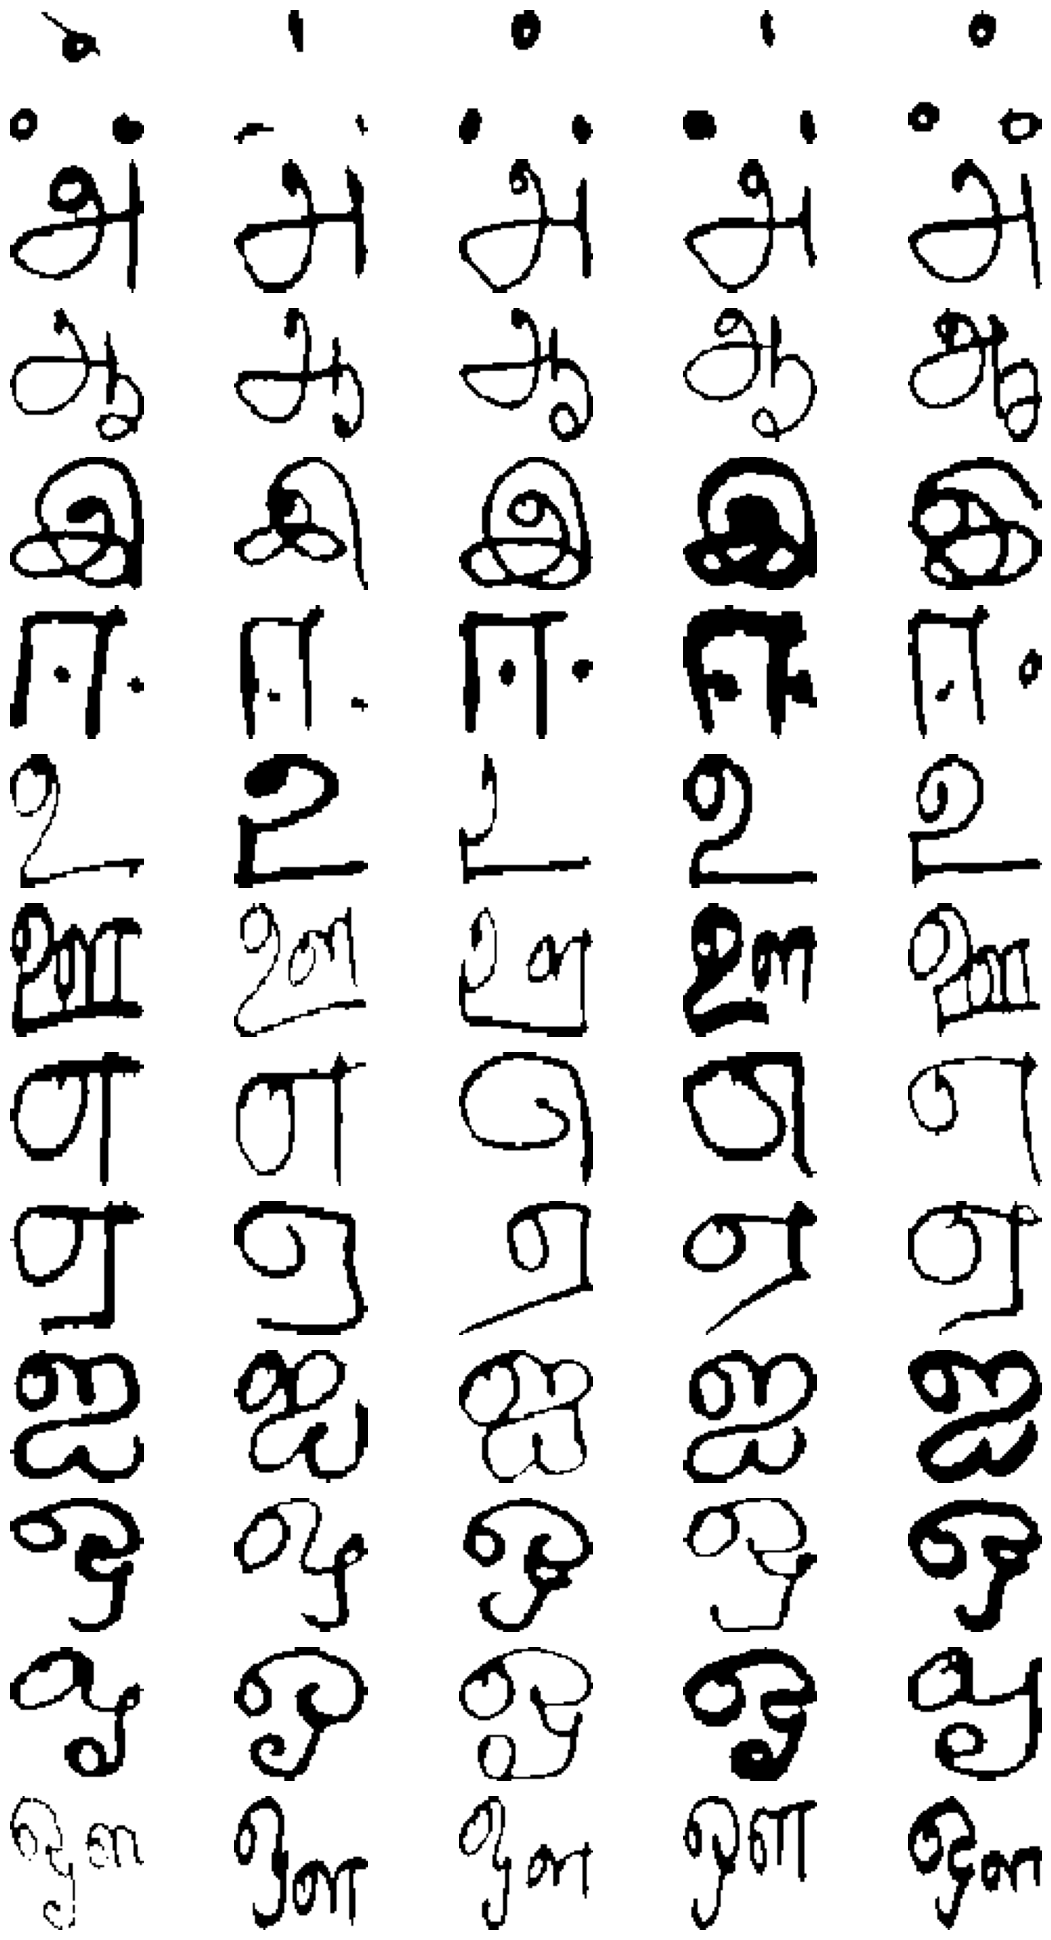

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from tqdm import tqdm
from collections import Counter
import seaborn as sns

# Constants
IMAGE_HEIGHT = 64
IMAGE_WIDTH = 64

# Paths
train_input_folder = "C:/DATASET/dataset2/train"
test_input_folder = "C:/DATASET/dataset2/test"
train_output_folder = "C:/DATASET/dataset2/preprocessed_train"
test_output_folder = "C:/DATASET/dataset2/preprocessed_test"

# Ensure output folders exist
os.makedirs(train_output_folder, exist_ok=True)
os.makedirs(test_output_folder, exist_ok=True)

# ------------- Preprocess Single Image -------------
def preprocess_image(image):
    image = cv2.resize(image, (IMAGE_WIDTH, IMAGE_HEIGHT))
    image = image.astype("float32") / 255.0
    return image

# ------------- Process Dataset (Train/Test) -------------
def process_dataset(input_folder, output_folder, dataset_type):
    if not os.path.exists(input_folder):
        print(f"Error: {dataset_type} folder not found -> {input_folder}")
        return

    for char_folder in tqdm(sorted(os.listdir(input_folder)), desc=f"Processing {dataset_type}"):
        char_path = os.path.join(input_folder, char_folder)
        save_path = os.path.join(output_folder, char_folder)
        os.makedirs(save_path, exist_ok=True)

        images = sorted(os.listdir(char_path))
        if not images:
            print(f"Warning: {dataset_type} folder {char_folder} is empty.")
            continue

        for img_name in images:
            if img_name.startswith("."):
                continue

            img_path = os.path.join(char_path, img_name)
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if image is None:
                print(f"Skipping corrupted file: {img_path}")
                continue

            preprocessed_image = preprocess_image(image)
            preprocessed_image = (preprocessed_image * 255).astype("uint8")

            save_img_path = os.path.join(save_path, "pre_" + os.path.splitext(img_name)[0] + ".png")
            cv2.imwrite(save_img_path, preprocessed_image)

    print(f"{dataset_type} Set: Preprocessed Successfully!")

# ------------- Load Images into Arrays -------------
def load_images(folder):
    images = []
    labels = []
    class_names = sorted([d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))])

    for class_index, class_name in enumerate(class_names):
        class_path = os.path.join(folder, class_name)

        for img_name in sorted(os.listdir(class_path)):
            if img_name.startswith(".") or not img_name.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                continue

            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                print(f"Skipping corrupted image: {img_path}")
                continue

            img = cv2.resize(img, (IMAGE_WIDTH, IMAGE_HEIGHT))
            img = img.astype("float32") / 255.0
            img = np.expand_dims(img, axis=-1)

            images.append(img)
            labels.append(class_index)  # numerical label

    return np.array(images), np.array(labels), class_names

# ------------- Visualization Helpers -------------
def plot_sample_images(images, labels, class_names, num=5):
    plt.figure(figsize=(10, 2))
    for i in range(num):
        plt.subplot(1, num, i + 1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title(f"Label: {labels[i]}\n({class_names[labels[i]]})", fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def plot_samples_by_class(images, labels, class_names, samples_per_class=5):
    plt.figure(figsize=(12, len(class_names) * 1.5))
    for idx, class_name in enumerate(class_names):
        class_indices = np.where(labels == idx)[0][:samples_per_class]
        for j, image_idx in enumerate(class_indices):
            plt.subplot(len(class_names), samples_per_class, idx * samples_per_class + j + 1)
            plt.imshow(images[image_idx].squeeze(), cmap='gray')
            plt.axis('off')
            if j == 0:
                plt.ylabel(class_name, rotation=0, labelpad=30, fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_class_distribution(labels, class_names):
    counter = Counter(labels)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=class_names, y=[counter[i] for i in range(len(class_names))])
    plt.xticks(rotation=90)
    plt.title("Class Distribution")
    plt.show()

# ------------- Full Pipeline -------------
if __name__ == "__main__":
    # Step 1: Process and save preprocessed images
    process_dataset(train_input_folder, train_output_folder, "Training")
    process_dataset(test_input_folder, test_output_folder, "Testing")

    # Step 2: Load preprocessed images
    X_train, y_train, class_names = load_images(train_output_folder)
    X_val, y_val, _ = load_images(test_output_folder)

    # Shuffle training set
    #X_train, y_train = shuffle(X_train, y_train, random_state=42)

    # Step 3: Save data
    np.savez_compressed("processed_data.npz",
                        X_train=X_train, y_train=y_train,
                        X_val=X_val, y_val=y_val,
                        class_names=class_names)

    print(" All preprocessing done. Saved as 'processed_data.npz'")
    print(f"Training Set: {X_train.shape}, Classes: {len(class_names)}")

    # Step 4: Visual Checks
    plot_sample_images(X_train, y_train, class_names)
    plot_class_distribution(y_train, class_names)
    plot_samples_by_class(X_train, y_train, class_names)


Processing:   0%|                                                                               | 0/13 [00:00<?, ?it/s]

Showing patching for class: 00, image: pre_1008.png


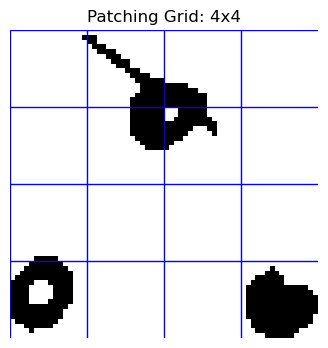

Processing:   8%|█████▍                                                                 | 1/13 [00:00<00:06,  1.95it/s]

Showing patching for class: 01, image: pre_10079.png


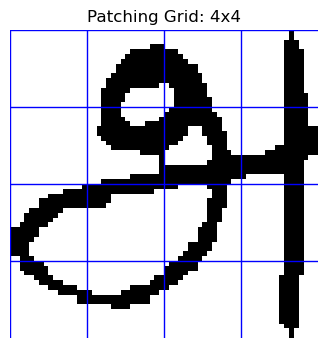

Processing:  15%|██████████▉                                                            | 2/13 [00:00<00:05,  2.03it/s]

Showing patching for class: 02, image: pre_10358.png


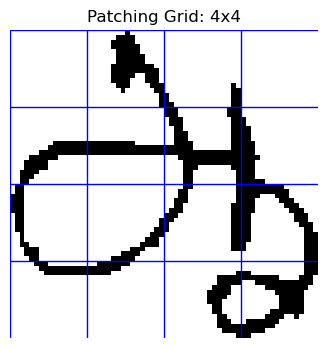

Processing:  23%|████████████████▍                                                      | 3/13 [00:01<00:04,  2.08it/s]

Showing patching for class: 03, image: pre_1000.png


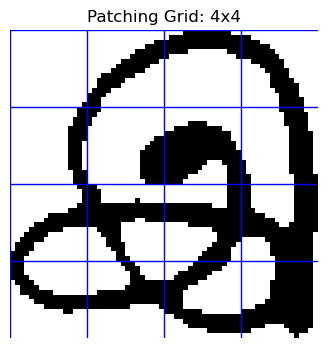

Processing:  31%|█████████████████████▊                                                 | 4/13 [00:01<00:04,  2.07it/s]

Showing patching for class: 04, image: pre_1001.png


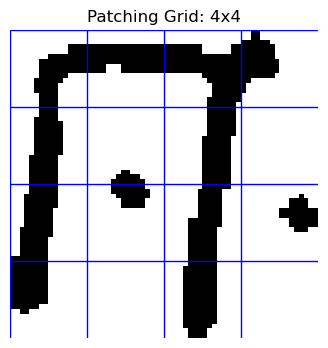

Processing:  38%|███████████████████████████▎                                           | 5/13 [00:02<00:03,  2.10it/s]

Showing patching for class: 05, image: pre_100.png


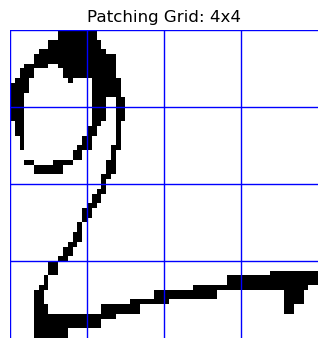

Processing:  46%|████████████████████████████████▊                                      | 6/13 [00:02<00:03,  2.07it/s]

Showing patching for class: 06, image: pre_1003.png


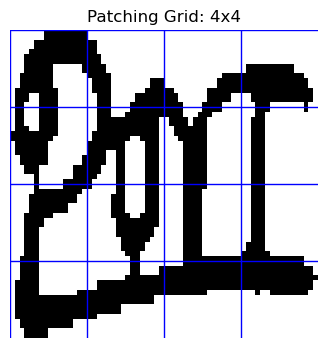

Processing:  54%|██████████████████████████████████████▏                                | 7/13 [00:03<00:02,  2.04it/s]

Showing patching for class: 07, image: pre_10081.png


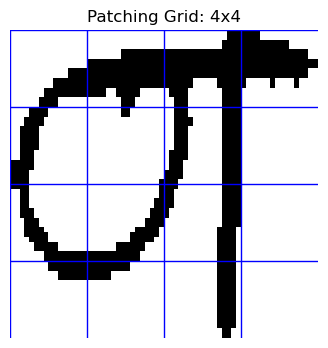

Processing:  62%|███████████████████████████████████████████▋                           | 8/13 [00:03<00:02,  2.04it/s]

Showing patching for class: 08, image: pre_10082.png


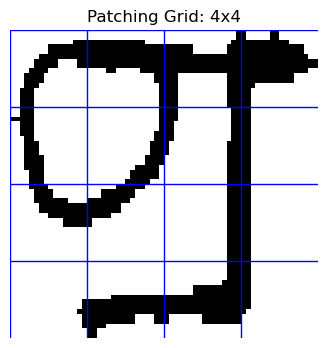

Processing:  69%|█████████████████████████████████████████████████▏                     | 9/13 [00:04<00:01,  2.04it/s]

Showing patching for class: 09, image: pre_1004.png


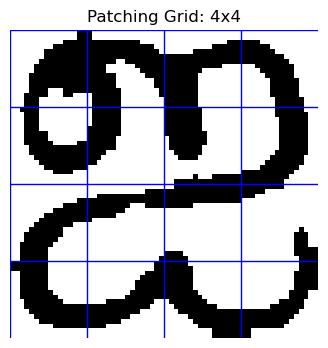

Processing:  77%|█████████████████████████████████████████████████████▊                | 10/13 [00:04<00:01,  2.03it/s]

Showing patching for class: 10, image: pre_1005.png


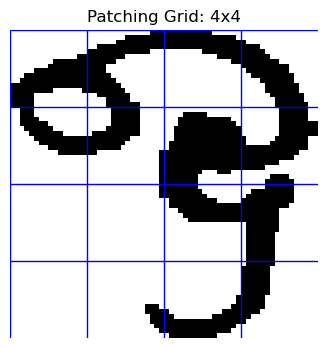

Processing:  85%|███████████████████████████████████████████████████████████▏          | 11/13 [00:05<00:00,  2.06it/s]

Showing patching for class: 11, image: pre_1022.png


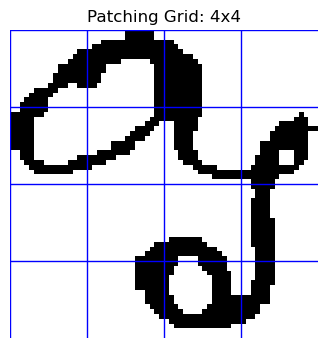

Processing:  92%|████████████████████████████████████████████████████████████████▌     | 12/13 [00:05<00:00,  2.05it/s]

Showing patching for class: 12, image: pre_10.png


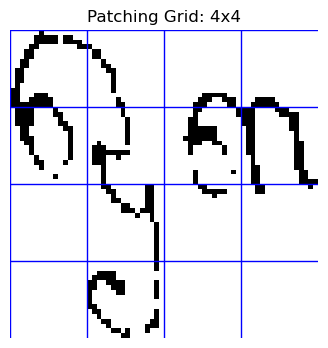

Processing: 100%|██████████████████████████████████████████████████████████████████████| 13/13 [00:06<00:00,  2.03it/s]

 All images patched, projected, and encoded.
 Final shape: (4172, 16, 512)


In [2]:
import os
import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

# Paths
input_folder = "C:/DATASET/dataset2/preprocessed_train"
patches_folder = "C:/DATASET/dataset2/patches_train"
os.makedirs(patches_folder, exist_ok=True)

# Model Parameters
PATCH_SIZE = 16
IMAGE_SIZE = 64
D_MODEL = 512
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2

# Random Projection Matrix (Fixed seed for reproducibility)
np.random.seed(42)
W = np.random.randn(PATCH_SIZE * PATCH_SIZE, D_MODEL).astype("float32")

# Positional Encoding
def positional_encoding(n_patches, d_model):
    positions = np.arange(n_patches)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
    encoding = np.zeros((n_patches, d_model), dtype=np.float32)
    encoding[:, 0::2] = np.sin(positions * div_term)
    encoding[:, 1::2] = np.cos(positions * div_term)
    return encoding

pos_encoding = positional_encoding(NUM_PATCHES, D_MODEL)

# Grid Plot Function
def plot_patching_grid(image, patch_size=PATCH_SIZE):
    """
    Shows image with grid lines representing patch boundaries.
    """
    h, w = image.shape
    plt.figure(figsize=(4, 4))
    plt.imshow(image, cmap="gray")

    for y in range(0, h, patch_size):
        plt.axhline(y=y - 0.5, color='blue', linewidth=1)
    for x in range(0, w, patch_size):
        plt.axvline(x=x - 0.5, color='blue', linewidth=1)

    plt.title(f"Patching Grid: {IMAGE_SIZE // PATCH_SIZE}x{IMAGE_SIZE // PATCH_SIZE}")
    plt.axis("off")
    plt.show()

# Main Processing
def process_images(input_folder, patches_folder, show_grid=True):
    all_projected_patches = []

    for class_name in tqdm(os.listdir(input_folder), desc="Processing"):
        class_path = os.path.join(input_folder, class_name)
        save_path = os.path.join(patches_folder, class_name)
        os.makedirs(save_path, exist_ok=True)

        shown = False  # Only show one sample per class
        for img_name in os.listdir(class_path):
            if not img_name.lower().endswith((".png", ".bmp", ".jpg", ".jpeg")):
                continue

            img_path = os.path.join(class_path, img_name)
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if image is None:
                print(f"Skipping: {img_path}")
                continue

            if show_grid and not shown:
                print(f"Showing patching for class: {class_name}, image: {img_name}")
                plot_patching_grid(image)
                shown = True

            # Extract patches
            patches = [
                image[y:y+PATCH_SIZE, x:x+PATCH_SIZE].flatten().astype("float32") / 255.0
                for y in range(0, IMAGE_SIZE, PATCH_SIZE)
                for x in range(0, IMAGE_SIZE, PATCH_SIZE)
            ]
            patches = np.array(patches)
            projected = patches @ W
            encoded = projected + pos_encoding

            # Save
            np.save(os.path.join(save_path, img_name.replace(".png", ".npy")), encoded)
            all_projected_patches.append(encoded)

    return np.array(all_projected_patches, dtype=np.float32)

# Run
final_data = process_images(input_folder, patches_folder, show_grid=True)
print(" All images patched, projected, and encoded.")
print(" Final shape:", final_data.shape)


In [5]:
import numpy as np

# Define MHSA Parameters
D_MODEL = 512  # Embedding Dimension
NUM_HEADS = 8  # Number of Attention Heads
D_HEAD = D_MODEL // NUM_HEADS  # Size per Head

# Function to Compute Multi-Head Self-Attention
def multi_head_self_attention(x):
    """
    Applies Multi-Head Self-Attention (MHSA) on the input patches.

    Args:
    - x: numpy array of shape (N, 49, 512) -> Patches after linear projection

    Returns:
    - Output after MHSA of shape (N, 49, 512)
    """
    N, P, D = x.shape  # N = Batch Size, P = Number of Patches, D = Embedding Dimension

    # Create Random Weights for Q, K, V
    W_q = np.random.randn(D_MODEL, D_MODEL).astype("float32")
    W_k = np.random.randn(D_MODEL, D_MODEL).astype("float32")
    W_v = np.random.randn(D_MODEL, D_MODEL).astype("float32")

    # Compute Query, Key, and Value
    Q = np.dot(x, W_q)  # (N, 49, 512)
    K = np.dot(x, W_k)  # (N, 49, 512)
    V = np.dot(x, W_v)  # (N, 49, 512)

    # Split into Multiple Heads
    Q = Q.reshape(N, P, NUM_HEADS, D_HEAD).transpose(0, 2, 1, 3)  # (N, 8, 16, 64)
    K = K.reshape(N, P, NUM_HEADS, D_HEAD).transpose(0, 2, 1, 3)  # (N, 8, 16, 64)
    V = V.reshape(N, P, NUM_HEADS, D_HEAD).transpose(0, 2, 1, 3)  # (N, 8, 16, 64)

    # Compute Attention Scores (QK^T / sqrt(d))
    attn_scores = np.matmul(Q, K.transpose(0, 1, 3, 2)) / np.sqrt(D_HEAD)  # (N, 8, 16, 16)

    #  Fix: Apply Softmax Correctly (Avoid Overflow)
    attn_scores = attn_scores - np.max(attn_scores, axis=-1, keepdims=True)  # Normalize before exp()
    attn_weights = np.exp(attn_scores) / np.sum(np.exp(attn_scores), axis=-1, keepdims=True)  # (N, 8, 16, 16)

    # Multiply Attention Weights with Values
    attn_output = np.matmul(attn_weights, V)  # (N, 8, 16, 64)

    # Concatenate Heads
    attn_output = attn_output.transpose(0, 2, 1, 3).reshape(N, P, D_MODEL)  # (N, 16, 512)

    return attn_output

# Apply MHSA
mhsa_output = multi_head_self_attention(final_data)
print("After MHSA:", mhsa_output.shape)  # Should be (N, 16, 512)


After MHSA: (4172, 16, 512)


In [7]:
import numpy as np

# Parameters
D_MODEL = 512       # Input/Output dimension
D_FF = 2048         # Expanded hidden layer

# Initialize Weights and Biases
W1 = np.random.randn(D_MODEL, D_FF).astype("float32")  # (512, 2048)
b1 = np.zeros(D_FF).astype("float32")                  # (2048,)

W2 = np.random.randn(D_FF, D_MODEL).astype("float32")  # (2048, 512)
b2 = np.zeros(D_MODEL).astype("float32")               # (512,)

# Layer Normalization
def layer_norm(x, eps=1e-6):
    mean = np.mean(x, axis=-1, keepdims=True)
    var = np.var(x, axis=-1, keepdims=True)
    return (x - mean) / np.sqrt(var + eps)

# Feed Forward Network with Residual & LayerNorm
def feed_forward_network(X):
    """
    Implements Transformer FFN block.

    Args:
    - X: shape (N, 16, 512)

    Returns:
    - Output: (N, 16, 512)
    """
    X_proj = np.dot(X, W1) + b1           # (N, 16, 2048)
    X_proj = np.maximum(0, X_proj)        # ReLU
    X_proj = np.dot(X_proj, W2) + b2      # (N, 16, 512)
    
    # Residual + Layer Norm
    output = layer_norm(X + X_proj)       # (N, 16, 512)
    return output

# Apply FFN to MHSA output
ffn_output = feed_forward_network(mhsa_output)
print("After FFN:", ffn_output.shape)  # Should be: (N, 16, 512)


After FFN: (4172, 16, 512)


In [9]:
import numpy as np

# Transformer Encoder Layer
def transformer_encoder(X):
    """
    Single Transformer Encoder Layer:
    - Multi-Head Self-Attention
    - Residual Connection & Layer Normalization
    - Feed-Forward Network
    
    Args:
    - X: Input tensor of shape (N, 49, 512)
    
    Returns:
    - Output tensor of shape (N, 49, 512)
    """
    # Multi-Head Self-Attention
    attn_output = multi_head_self_attention(X)  # (N, 49, 512)
    X = layer_norm(X + attn_output)  # Residual + LayerNorm
    
    # Feed-Forward Network
    output = feed_forward_network(X)  # (N, 49, 512)
    
    return output

# Stack Transformer Encoder Layers
def transformer_stack(X, num_layers=6):
    """
    Stacks multiple Transformer Encoder Layers.
    
    Args:
    - X: Input tensor of shape (N, 49, 512)
    - num_layers: Number of encoder layers to apply
    
    Returns:
    - Output tensor of shape (N, 49, 512)
    """
    for _ in range(num_layers):
        X = transformer_encoder(X)  # Apply each layer
    return X

# Apply Stacked Transformer Layers

final_transformer_output = transformer_stack(mhsa_output)  
print("After Stacked Transformer Encoders:", final_transformer_output.shape)  


After Stacked Transformer Encoders: (4172, 16, 512)


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Constants
NUM_CLASSES = len(class_names)  # Total number of Tamil character classes
PATCHES = 64
EMBED_DIM =64

# Inputs (Assume each input image is already patch embedded: 196 patches of 512 dims)
inputs = tf.keras.Input(shape=(PATCHES, EMBED_DIM))

# Transformer Block(s)
def transformer_block(x, num_heads=8, mlp_dim=512, dropout=0.2):
    # Layer Norm
    x_norm1 = layers.LayerNormalization(epsilon=1e-6)(x)
    # Multi-head self-attention
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=EMBED_DIM)(x_norm1, x_norm1)
    attn_output = layers.Dropout(dropout)(attn_output)
    x1 = layers.Add()([x, attn_output])  # Skip connection

    # FFN
    x_norm2 = layers.LayerNormalization(epsilon=1e-6)(x1)
    ffn_output = layers.Dense(mlp_dim, activation="gelu")(x_norm2)
    ffn_output = layers.Dense(EMBED_DIM)(ffn_output)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.Add()([x1, ffn_output])  # Skip connection

# Stack multiple transformer blocks (e.g., 4)
x = inputs
for _ in range(6):
    x = transformer_block(x)

# Global Average Pooling
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.2)(x)

# Step 8: Classification Head
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

# Build Model
vit_model = models.Model(inputs, outputs)

#: Compile with Loss & Optimizer
vit_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# : Training Loop
history = vit_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=64,
    batch_size=64
)

# Optional Evaluation
val_loss, val_acc = vit_model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")



Epoch 1/64
66/66 ━━━━━━━━━━━━━━━━━━━━ 66s 702ms/step - accuracy: 0.4341 - loss: 1.8018 - val_accuracy: 0.6933 - val_loss: 0.9398
Epoch 2/64
66/66 ━━━━━━━━━━━━━━━━━━━━ 45s 677ms/step - accuracy: 0.6905 - loss: 0.9372 - val_accuracy: 0.7644 - val_loss: 0.6860
Epoch 3/64
66/66 ━━━━━━━━━━━━━━━━━━━━ 46s 689ms/step - accuracy: 0.7766 - loss: 0.6646 - val_accuracy: 0.7875 - val_loss: 0.6393
Epoch 4/64
66/66 ━━━━━━━━━━━━━━━━━━━━ 46s 691ms/step - accuracy: 0.8134 - loss: 0.5446 - val_accuracy: 0.8365 - val_loss: 0.4801
Epoch 5/64
66/66 ━━━━━━━━━━━━━━━━━━━━ 46s 689ms/step - accuracy: 0.8397 - loss: 0.4802 - val_accuracy: 0.8356 - val_loss: 0.4869
Epoch 6/64
66/66 ━━━━━━━━━━━━━━━━━━━━ 45s 682ms/step - accuracy: 0.8752 - loss: 0.3861 - val_accuracy: 0.8519 - val_loss: 0.4378
Epoch 7/64
66/66 ━━━━━━━━━━━━━━━━━━━━ 45s 681ms/step - accuracy: 0.8911 - loss: 0.3134 - val_accuracy: 0.8462 - val_loss: 0.4732
Epoch 8/64
66/66 ━━━━━━━━━━━━━━━━━━━━ 46s 695ms/step - accuracy: 0.8876 - loss: 0.3117 - val_accu

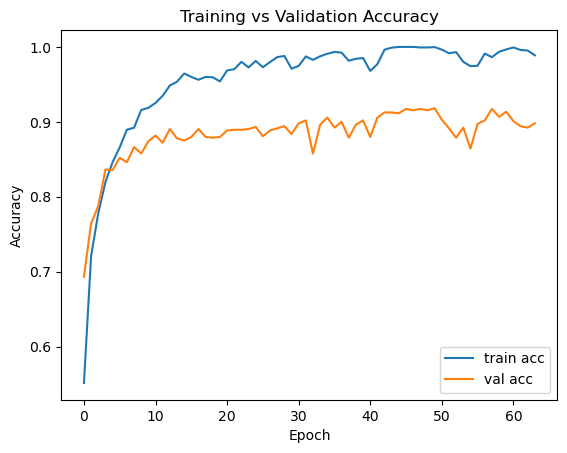

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()


In [17]:
label_to_tamil = {
    0: "ஃ", 1: "அ", 2: "ஆ", 3: "இ", 4: "ஈ", 5: "உ", 6: "ஊ",
    7: "எ", 8: "ஏ", 9: "ஐ", 10: "ஒ", 11: "ஓ", 12: "ஔ"
}
for i in range(13):
    print(i, label_to_tamil[i])


0 ஃ
1 அ
2 ஆ
3 இ
4 ஈ
5 உ
6 ஊ
7 எ
8 ஏ
9 ஐ
10 ஒ
11 ஓ
12 ஔ


In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predict on test data
y_pred_probs = vit_model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification report
print("Classification Report:")
print(classification_report(y_val, y_pred))


33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        80
           1       0.87      0.95      0.91        80
           2       0.92      0.89      0.90        80
           3       0.92      0.89      0.90        80
           4       0.95      0.89      0.92        80
           5       0.96      0.97      0.97        80
           6       0.99      0.95      0.97        80
           7       0.91      0.89      0.90        80
           8       0.94      0.90      0.92        80
           9       0.85      0.93      0.89        80
          10       0.88      0.64      0.74        80
          11       0.66      0.82      0.73        80
          12       0.91      0.97      0.94        80

    accuracy                           0.90      1040
   macro avg       0.90      0.90      0.90      1040
weighted avg       0.90      0.90      0.90      1040



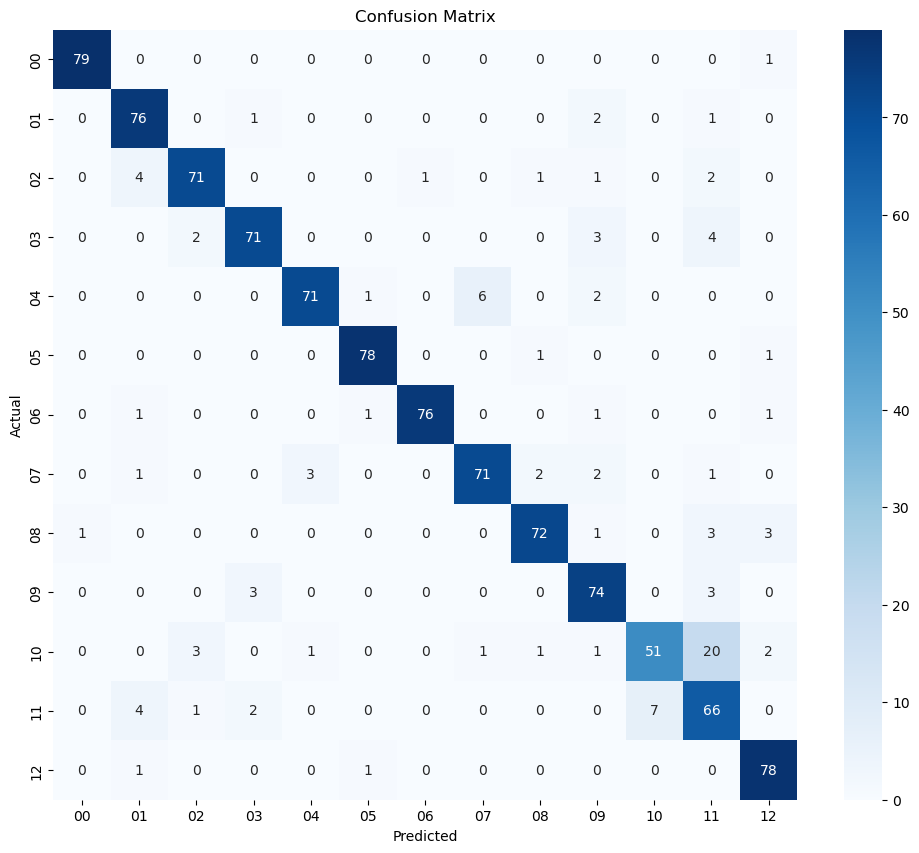

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [23]:
vit_model.save('my_vit_model3.keras')  # Recommended


In [25]:
from tensorflow.keras.models import load_model

model = load_model('my_vit_model3.keras')


In [27]:
from matplotlib import font_manager

# Add to Matplotlib's font manager
font_path = "C:/Users/ishwa/Latha.ttf"
font_manager.fontManager.addfont(font_path)

# Get the name recognized by Matplotlib
latha_font = font_manager.FontProperties(fname=font_path)
print("Registered font name:", latha_font.get_name())

# Set it globally
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = latha_font.get_name()


Registered font name: Latha


 Found 15 image(s) in 'C:/DATASET/Dataset/Test/11-Oa'
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[6.2882763e-12 3.7878758e-12 1.6849155e-10 2.6453069e-12 1.2903658e-12
 1.2925959e-11 1.6000815e-14 5.7317936e-15 7.2124300e-13 7.0249449e-13
 3.3258160e-11 9.9999952e-01 4.3960191e-07]
50004.bmp → Predicted: ஓ (Confidence: 100.00%)


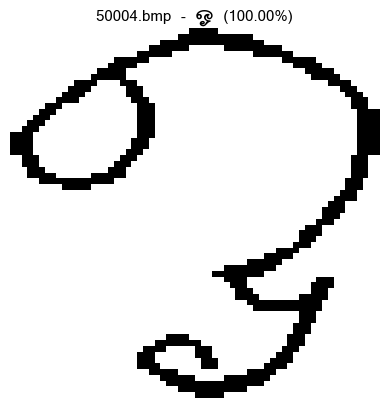

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[4.8665055e-11 2.4894583e-11 1.5356603e-11 2.9958253e-10 4.5233990e-11
 2.3849428e-10 1.9845855e-13 3.0894097e-13 3.4585852e-11 4.0703701e-11
 6.3106702e-09 9.9999952e-01 5.2317051e-07]
51735.bmp → Predicted: ஓ (Confidence: 100.00%)


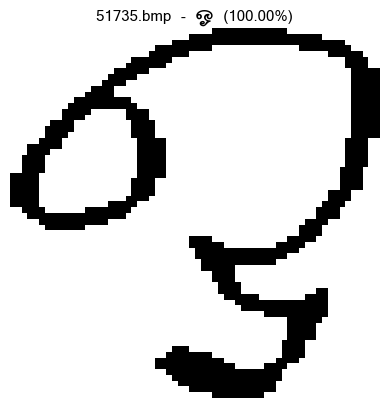

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
[5.2735141e-09 2.0513855e-09 2.9099808e-06 1.4886493e-09 1.2568668e-10
 3.8390406e-09 7.6823513e-12 6.8461370e-14 1.8296586e-10 7.4598621e-09
 2.8106223e-08 9.9999702e-01 7.8874891e-08]
51892.bmp → Predicted: ஓ (Confidence: 100.00%)


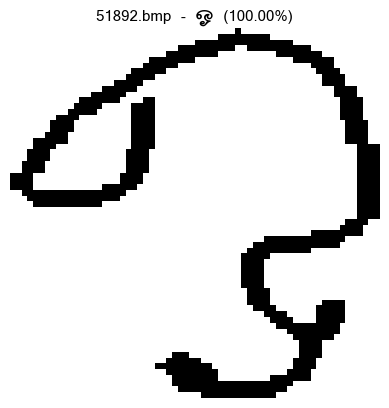

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
[5.1129163e-11 1.6032235e-11 1.4149357e-09 5.9167097e-13 2.2343670e-11
 9.9019064e-11 3.4262626e-13 1.0991091e-12 7.8724258e-12 4.0484786e-11
 1.1172879e-06 9.9999881e-01 8.8370726e-08]
52991.bmp → Predicted: ஓ (Confidence: 100.00%)


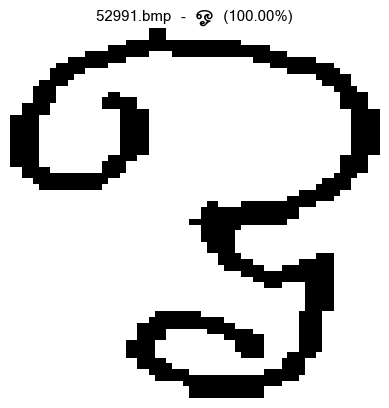

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
[3.70066942e-07 1.91111527e-09 1.19676535e-08 7.42855673e-06
 3.31071021e-07 5.50889672e-06 4.79424972e-11 9.23776433e-09
 8.56806039e-08 1.16083611e-05 4.54932362e-01 5.45004904e-01
 3.73683251e-05]
54090.bmp → Predicted: ஓ (Confidence: 54.50%)


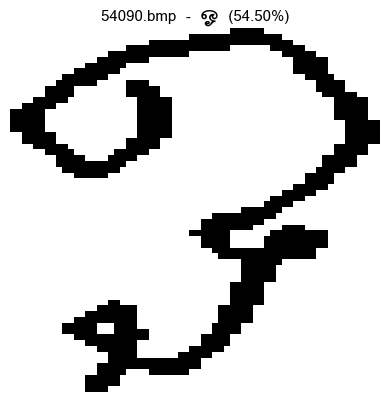

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
[1.5793587e-08 2.2215449e-09 1.3320707e-04 5.8175625e-10 1.8539625e-09
 3.2907682e-08 1.2444956e-11 4.3015948e-11 7.2518942e-09 7.0717001e-09
 1.4134138e-05 9.9985051e-01 2.0857656e-06]
54247.bmp → Predicted: ஓ (Confidence: 99.99%)


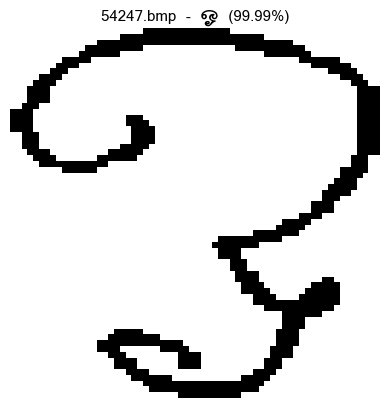

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
[2.1526017e-09 6.1841931e-08 8.0779550e-10 6.4923018e-11 4.1611008e-07
 9.6720214e-08 2.3168628e-11 3.1688774e-08 7.6425358e-08 3.2598290e-08
 7.6710212e-04 9.9893445e-01 2.9765672e-04]
54404.bmp → Predicted: ஓ (Confidence: 99.89%)


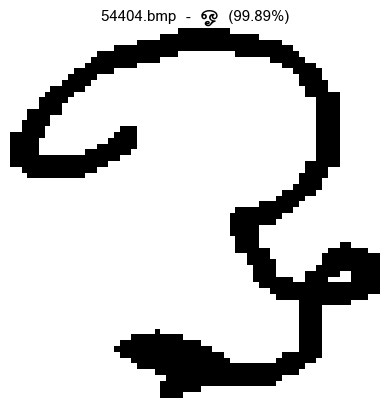

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
[4.1605591e-10 3.6888447e-13 1.9718771e-09 3.1138110e-09 1.8796854e-08
 8.2408230e-10 5.3166633e-12 3.2218360e-08 4.9363827e-08 1.0231112e-06
 9.9504858e-01 4.9465322e-03 3.7043164e-06]
626.bmp → Predicted: ஒ (Confidence: 99.50%)


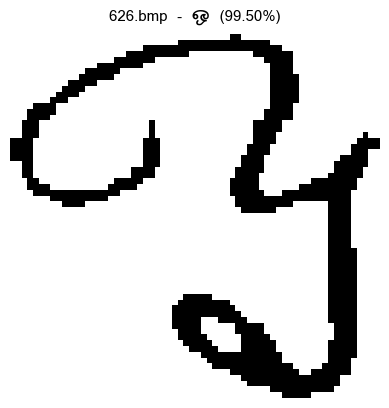

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
[7.9102647e-06 1.3597435e-04 6.2140483e-05 1.3746788e-03 3.6854060e-06
 4.7585304e-06 9.5807628e-08 1.2483701e-05 2.5559684e-06 7.1634531e-05
 9.1543621e-01 7.8823097e-02 4.0648603e-03]
686.bmp → Predicted: ஒ (Confidence: 91.54%)


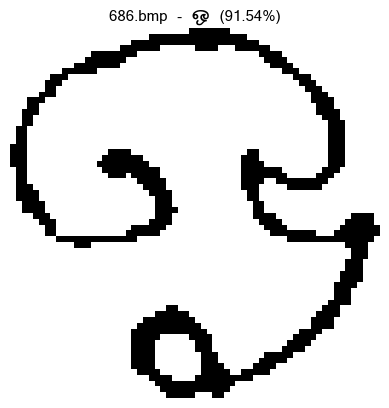

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
[5.2088469e-11 2.6049067e-09 3.2336297e-11 2.1661175e-03 4.2981868e-11
 4.5938886e-08 3.4876824e-11 3.5678494e-12 2.1917521e-10 1.8585690e-05
 2.2474783e-04 9.9758840e-01 1.9844917e-06]
750.bmp → Predicted: ஓ (Confidence: 99.76%)


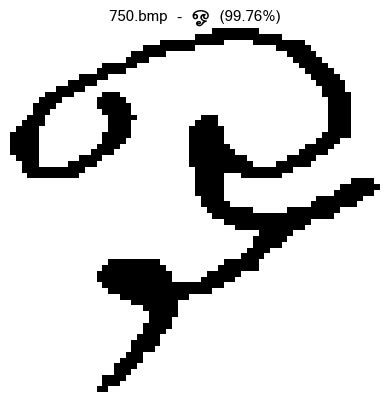

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
[8.79072468e-06 8.91610966e-07 1.08622004e-07 6.21503495e-05
 3.34519355e-05 1.61204553e-05 1.37554190e-09 1.36495728e-05
 3.82613711e-04 3.21943834e-02 9.36672866e-01 6.45986234e-04
 2.99690291e-02]
766.bmp → Predicted: ஒ (Confidence: 93.67%)


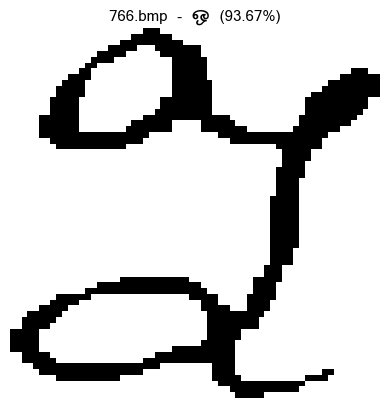

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
[9.8217024e-06 1.9705854e-07 1.2273581e-02 7.4846724e-08 1.1138212e-04
 2.7719241e-06 1.9775435e-09 1.5648062e-05 6.9762791e-07 5.6774006e-05
 9.7130042e-01 5.5608009e-03 1.0667927e-02]
846.bmp → Predicted: ஒ (Confidence: 97.13%)


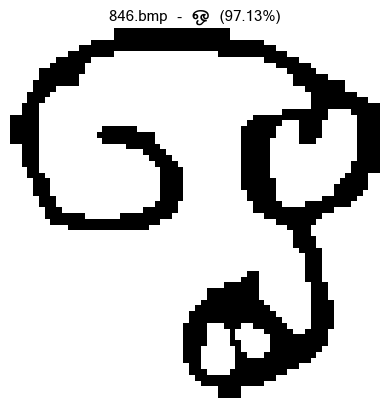

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
[2.9608165e-08 9.4285646e-09 4.8930622e-07 2.6719686e-06 1.3047020e-08
 2.6150192e-07 2.8044289e-10 1.7713114e-09 8.0256008e-08 4.3479064e-05
 4.4779649e-01 5.5215603e-01 4.1496952e-07]
926.bmp → Predicted: ஓ (Confidence: 55.22%)


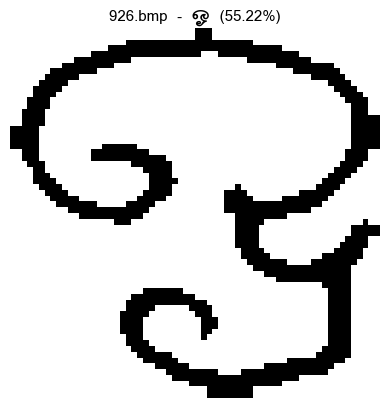

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
[7.7010078e-08 9.9997902e-01 2.0732508e-05 6.6217240e-08 5.4082888e-12
 3.0439484e-11 7.5448064e-10 8.3431910e-13 6.9772525e-12 2.9395958e-11
 3.0542232e-16 2.6346033e-12 2.5752383e-11]
942.bmp → Predicted: அ (Confidence: 100.00%)


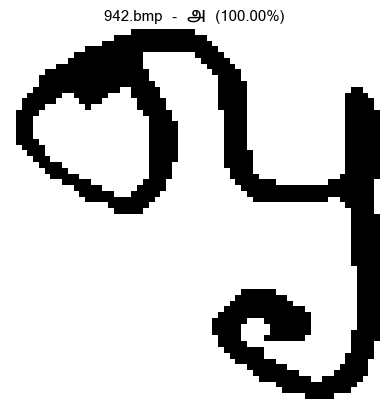

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
[9.65080835e-05 2.17837572e-01 7.78490957e-03 6.66430950e-01
 3.34113770e-06 1.39409767e-05 2.00441559e-06 1.06075966e-07
 4.72459583e-08 2.05524906e-04 6.87687934e-05 1.07444905e-01
 1.11512978e-04]
974.bmp → Predicted: இ (Confidence: 66.64%)


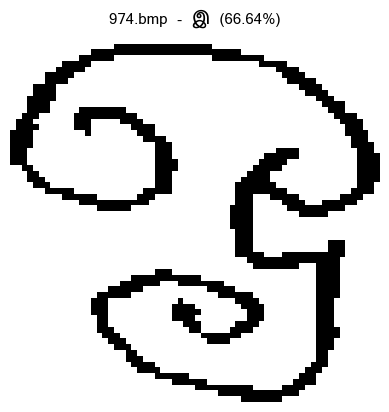

In [29]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model("my_vit_model3.keras")


label_to_tamil = {
    0: "ஃ", 1: "அ", 2: "ஆ", 3: "இ", 4: "ஈ", 5: "உ", 6: "ஊ",
    7: "எ", 8: "ஏ", 9: "ஐ", 10: "ஒ", 11: "ஓ", 12: "ஔ"
}


dataset_path = "C:/DATASET/Dataset/Test/11-Oa" 


all_files = os.listdir(dataset_path)
image_files = [f for f in all_files if f.lower().endswith(('.bmp', '.png', '.jpg', '.jpeg'))]

print(f" Found {len(image_files)} image(s) in '{dataset_path}'")

for filename in image_files:
    img_path = os.path.join(dataset_path, filename)

    # Load image in grayscale
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f" Skipped unreadable file: {filename}")
        continue

    # Resize and normalize
    image = cv2.resize(image, (64, 64))
    image = image.astype("float32") / 255.0

    # Add channel and batch dimensions
    image_input = np.expand_dims(image, axis=-1)  # (196, 196, 1)
    image_input = np.expand_dims(image_input, axis=0)  # (1, 196, 196, 1)

    # Predict
    probs = model.predict(image_input)[0]
    
    print(probs)
    pred_label = np.argmax(probs)
    confidence = probs[pred_label]

    # Display results
    print(f"{filename} → Predicted: {label_to_tamil[pred_label]} (Confidence: {confidence:.2%})")
    plt.imshow(image, cmap='gray')
    plt.title(f"{filename} - {label_to_tamil[pred_label]} ({confidence:.2%})")
    plt.axis('off')
    plt.show()


In [4]:
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load model
model = load_model("my_vit_model3.keras")

# Label to character mapping
label_to_tamil = {
    0: "ஃ", 1: "அ", 2: "ஆ", 3: "இ", 4: "ஈ", 5: "உ", 6: "ஊ",
    7: "எ", 8: "ஏ", 9: "ஐ", 10: "ஒ", 11: "ஓ", 12: "ஔ"
}

# Placeholder for image path
selected_image_path = None

# Function to open file dialog
def select_image():
    global selected_image_path
    selected_image_path = filedialog.askopenfilename(
        filetypes=[("Image Files", "*.png *.jpg *.bmp *.jpeg")])
    
    if selected_image_path:
        img = Image.open(selected_image_path)
        img = img.resize((200, 200))
        img_tk = ImageTk.PhotoImage(img)
        panel.config(image=img_tk)
        panel.image = img_tk

# Function to preprocess and predict
def upload_and_predict():
    if selected_image_path is None:
        print("No image selected.")
        return
    
    # Read and preprocess image
    img = cv2.imread(selected_image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (64, 64))
    img = img.astype(np.float32) / 255.0
    input_img = np.expand_dims(img, axis=(0, -1))  # Shape: (1, 196, 196, 1)

    # Predict
    pred = model.predict(input_img)
    predicted_label = np.argmax(pred[0])
    tamil_char = label_to_tamil[predicted_label]

    # Display result
    print(f"Predicted Tamil character: {tamil_char}")
    result_label.config(text=f"Predicted: {tamil_char}")

# Tkinter window
root = tk.Tk()
root.title("Tamil Character Predictor")

btn1 = tk.Button(root, text="Select Image", command=select_image)
btn1.pack()

btn2 = tk.Button(root, text="Upload and Predict", command=upload_and_predict)
btn2.pack()

panel = tk.Label(root)
panel.pack()

result_label = tk.Label(root, text="", font=("Helvetica", 16))
result_label.pack()

root.mainloop()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Tamil character: ஐ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Predicted Tamil character: எ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Predicted Tamil character: அ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Predicted Tamil character: எ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Predicted Tamil character: எ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Predicted Tamil character: ஐ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Predicted Tamil character: எ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Predicted Tamil character: எ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Predicted Tamil character: எ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Predicted Tamil character: எ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Predicted Tamil character: ஈ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Predicted Tamil character: எ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Predicted Tamil character: எ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Predicted Tamil character: எ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Predicted Tamil characte